# Contemporary art as an asset class — a quantitative teardown 🔬
### Art index vs SPY (CAGR / vol / MDD + an annual-excess *t*) · Newey-West proxy alpha · the buyer's-premium + carry haircut on NAV · a synthetic bubble positive control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Art_beats_stocks%3F: Busted](https://img.shields.io/badge/Art_beats_stocks%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). We test the strongest tradable form of "contemporary art beats the S&P": (H₁) the secondary-market auction index out-returns SPY risk-adjusted; (H₂) a buyable proxy carries alpha vs the market; (H₃) it survives the transaction + carry cost of owning physical art. We find **H₁ rejected** (it *under*-performs), **H₂ rejected** (no significant alpha), **H₃ rejected** (negative net of costs).

> ⚠️ **Not investment advice — data provenance.** The art index is **hardcoded, cited, approximate** (public Artprice / Sotheby's Mei Moses reporting — a *labelled proxy*, never the live feed). Equity proxies `MCHN.SW`, `KER.PA`, `SPY` are month-end Adj Close via yfinance (as-of 2025-12-31). Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md); numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from art_auction_index import data, strategy as st

HAVE_PROXIES = data.have_proxies()
IDX = data.load_art_index()                          # hardcoded, cited, APPROXIMATE proxy
PROX = data.load_proxies() if HAVE_PROXIES else None
print("equity-proxy cache present:", HAVE_PROXIES,
      "| art-index years:", IDX.index[0].year, "->", IDX.index[-1].year)

# frozen headline numbers (mirror of docs/results.md)
R = {'win': '2000 → 2025', 'idx_levels': {2000: 100, 2001: 103, 2002: 100, 2003: 108, 2004: 128, 2005: 158, 2006: 205, 2007: 268, 2008: 232, 2009: 150, 2010: 205, 2011: 248, 2012: 250, 2013: 292, 2014: 330, 2015: 312, 2016: 292, 2017: 330, 2018: 352, 2019: 345, 2020: 322, 2021: 430, 2022: 478, 2023: 430, 2024: 385, 2025: 400}, 'peak_date': '2022-05', 'peak_level': 490, 'macklowe_musd': 922, 'crash_0709': -44.0, 'corr_2224': -19.5, 'idx_cagr': 5.7, 'idx_vol': 17.1, 'idx_sharpe': 0.41, 'idx_mdd': -44.0, 'spy_cagr_ye': 8.76, 'spy_vol_ye': 17.8, 'spy_mdd_ye': -36.8, 'excess_mean': -3.27, 'excess_t': -0.687, 'excess_p': 0.499, 'excess_n': 25, 'mchn_cagr': -6.85, 'mchn_vol': 31.5, 'mchn_sharpe': -0.07, 'mchn_mdd': -95.5, 'mchn_alpha': -7.74, 'mchn_beta': 0.6, 'mchn_t': -1.11, 'mchn_p': 0.268, 'mchn_n': 294, 'ker_cagr': 4.84, 'ker_vol': 32.6, 'ker_sharpe': 0.31, 'ker_mdd': -78.9, 'ker_alpha': -0.15, 'ker_beta': 1.12, 'ker_t': -0.03, 'ker_p': 0.977, 'ker_n': 311, 'spy_cagr': 8.23, 'spy_vol': 15.1, 'spy_sharpe': 0.6, 'spy_mdd': -50.8, 'carry_gross': 5.7, 'carry_spread': -4.58, 'carry_insure': -1.0, 'carry_net': -0.15, 'syn_peak': 589, 'syn_end': 175, 'syn_cagr': 5.31, 'syn_sharpe': 0.39, 'syn_mdd': -70.3}


equity-proxy cache present: True | art-index years: 2000 -> 2025


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Art index CAGR **5.7%** vs SPY **8.8%** (2000–2025); mean annual excess **-3.3%/yr**, *t* = **-0.69** (n=25). Proxies: no significant alpha (MCHN NW *t*=-1.11, KER *t*=-0.03). |
| **Tradability** | `MIRAGE` | Gross index CAGR **+5.7%** → **NET -0.1%/yr** after a ~25% buyer's premium + 10% seller's commission + 1%/yr carry. Auction houses all private; buyable proxy MCHN.SW maxDD **-96%**. |
| **Art beats the S&P?** | `BUSTED` | SPY wins CAGR (8.2 vs 5.7), Sharpe (0.60 vs 0.41), maxDD (-37 vs -44), and net-of-cost. Every column. |

> 💡 In plain words: the art market under-performed stocks with a deeper drawdown, the only thing you can buy is alpha-free (often disastrous) beta, and the auction-house frictions turn even the gross return negative. There is no axis on which "art beats the S&P" survives.

## 1 · The claim, steelmanned

Let the secondary-market index level be $I_t$ and the benchmark $B_t$ (SPY). The claim is a joint hypothesis:

- **H₁ (it out-returns).** Annual excess $\;x_t = r^I_t - r^B_t\;$ has $\mathbb{E}[x_t] > 0$ with $t > 2$ — art beats stocks *risk-adjusted*.
- **H₂ (it's buyable with alpha).** For a tradable proxy $P$, the intercept $\alpha$ in $r^P_t = \alpha + \beta r^B_t + \varepsilon_t$ is positive with a Newey-West *t* > 2.
- **H₃ (it survives premiums).** The net CAGR after a buyer's premium $b$ and seller's commission $c$ (round-trip multiple $(1-c)/(1+b)$) over hold $h$ and annual carry $k$ stays positive: $(1+g)\big((\tfrac{1-c}{1+b})^{1/h}\big)(1-k)-1 > 0$.

The 2000s and 2021–22 booms are the steelman: in each wave H₁ held *in-sample*. The test is whether it holds over the **full cycle, risk-adjusted, net of cost** — i.e. whether it's an asset class or a boom.

## 2 · So what? — what rides on each answer

If H₁–H₃ held, art would be a genuine diversifier: equity-beating return, hangable, low-correlation, inflation-proof — the exact pitch. But each leg is separately falsifiable. H₁ is a **return race** on a common clock. H₂ asks whether the *only investable expression* (listed equities) delivers anything beyond market beta — because you cannot custody "the index," and, uniquely here, **you cannot even buy the auction house** (Sotheby's, Christie's, Phillips are all private). H₃ is the **microstructure tax**: a physical lot carries a ~25% buyer's premium *and* a ~10% seller's commission with a multi-year holding period plus insurance carry, frictions an ETF never pays. The asset-class claim needs all three; failing any one downgrades it to a boom narrative.

## 3 · How we'd know — the protocol

- **Art index (proxy).** A hardcoded, cited, **approximate** annual level (base 100 @ 2000), reconstructed from public Artprice / Sotheby's Mei Moses / press figures (2000s melt-up, 2008–09 ~−44% crash, 2014 peak, 2021–22 records, 2023–24 ~−20% correction). *Labelled a proxy* — its path is defensible, its precise year-end values are not a live feed.
- **Equity proxies.** `MCHN.SW` (from its 2001 listing), `KER.PA`, `SPY` month-end Adj Close (yfinance, cached). Survivorship is **not** a concern here (named tickers, not a screen); the relevant caveat is the *reverse* — the cleanest expressions (the auction houses) **left** the tape (Sotheby's taken private 2019), so the listed set is a second-best, stated.
- **Signal test.** (i) Paired annual-excess $t$ of $r^I - r^B$ (n≈25, still weak by construction). (ii) **Newey-West (6-lag) HAC** $t$ of the proxy alpha vs SPY — the bar for `REAL` is *t* ≥ 2 in art's favour.
- **Cost (beat 6).** Charge the ~25% buyer's premium + ~10% seller's commission (a ~28% round-trip over a 7y hold) + 1%/yr carry **once on NAV**; net CAGR.
- **Positive control.** A deterministic bubble-and-round-trip path with a *planted* boom/bust drift; the engine must recover the up-sign and a finite Sharpe — proof a null on the real tape is a real null, not a broken harness.
- **What would make us say "asset class":** H₁ *t* > 2 **or** a proxy alpha *t* > 2, **and** a positive net-of-cost CAGR. We find none of these.

## 4 · The teardown

### 4a · The race — art index vs SPY, risk-adjusted

Year-end levels rebased to \$100, both series on one clock. CAGR, vol and max-drawdown in the print.

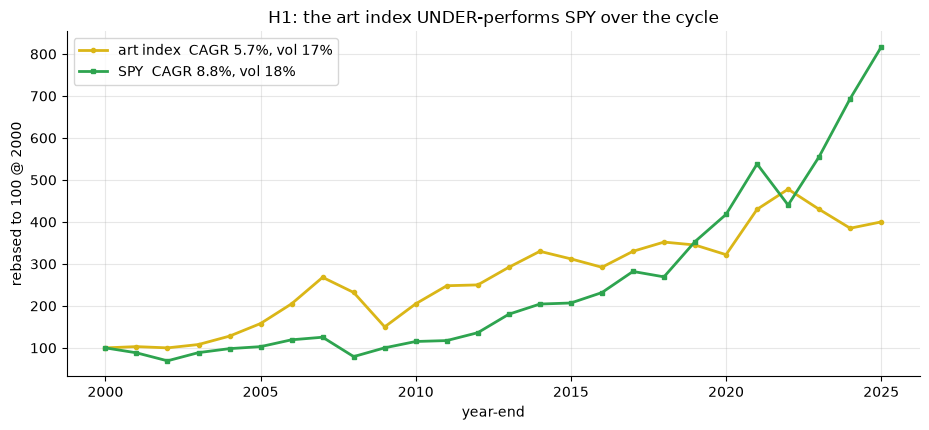

art: CAGR 5.70%  vol 17.1%  maxDD -44.0%
SPY: CAGR 8.76%  vol 17.8%  maxDD -36.8%
annual excess (art-SPY): mean -3.27%/yr  t=-0.687  (n=25)


In [2]:
yrs = list(R['idx_levels'].keys())
lv = np.array([float(IDX.loc[f'{y}-12-31']) for y in yrs])
if HAVE_PROXIES:
    spy_ye = PROX['SPY'].resample('YE').last()
    spy_ye = spy_ye[(spy_ye.index.year>=2000)&(spy_ye.index.year<=2025)]
    spy = (spy_ye/spy_ye.iloc[0]*100).values; sx=[d.year for d in spy_ye.index]
    si = st.summarize(IDX, periods_per_year=1.0)
    ss = st.summarize(spy_ye, periods_per_year=1.0)
    ae = st.annual_excess_t(IDX, PROX['SPY'])
else:
    spy = np.array([100*(1+R['spy_cagr_ye']/100)**(y-2000) for y in yrs]); sx=yrs
    si={'cagr':R['idx_cagr']/100,'vol':R['idx_vol']/100,'mdd':R['idx_mdd']/100}
    ss={'cagr':R['spy_cagr_ye']/100,'vol':R['spy_vol_ye']/100,'mdd':R['spy_mdd_ye']/100}
    ae={'mean_excess':R['excess_mean']/100,'t':R['excess_t'],'n':R['excess_n']}
fig, ax = plt.subplots(figsize=(9.4, 4.4))
ax.plot(yrs, lv, 'o-', c=AMBER, lw=2.0, ms=3, label=f"art index  CAGR {si['cagr']*100:.1f}%, vol {si['vol']*100:.0f}%")
ax.plot(sx, spy, 's-', c=GREEN, lw=2.0, ms=3, label=f"SPY  CAGR {ss['cagr']*100:.1f}%, vol {ss['vol']*100:.0f}%")
ax.set_xlabel('year-end'); ax.set_ylabel('rebased to 100 @ 2000')
ax.set_title('H1: the art index UNDER-performs SPY over the cycle'); ax.legend()
plt.tight_layout(); plt.show()
print(f"art: CAGR {si['cagr']*100:.2f}%  vol {si['vol']*100:.1f}%  maxDD {si['mdd']*100:.1f}%")
print(f"SPY: CAGR {ss['cagr']*100:.2f}%  vol {ss['vol']*100:.1f}%  maxDD {ss['mdd']*100:.1f}%")
print(f"annual excess (art-SPY): mean {ae['mean_excess']*100:+.2f}%/yr  t={ae['t']:+.3f}  (n={ae['n']})")

> 💡 In plain words: the art index compounds at **5.7%** against SPY's **8.8%**, with a *deeper* drawdown on the same annual clock — it loses on return and on risk. The mean annual excess is **-3.3%/yr**, *t* = **-0.69** (n=25): comfortably inside noise, and the point estimate is negative. H₁ rejected; the honest stamp is `NONE`, leaning negative.

### 4b · The buyable proxies — is there alpha, or just beta?

Newey-West (6-lag) regression of each proxy's **monthly** return on SPY. `REAL` needs $t_\alpha \ge 2$ in art's favour. (And note the cleanest expressions aren't here at all — the auction houses are private.)

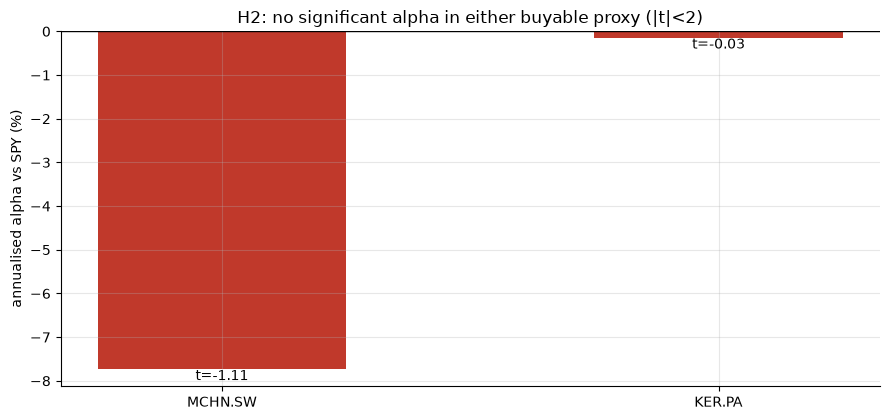

MCHN.SW  CAGR  -6.85%  Sharpe -0.07  maxDD  -95.5%  alpha -7.74%/yr  beta 0.60  NW t -1.11
KER.PA   CAGR   4.84%  Sharpe +0.31  maxDD  -78.9%  alpha -0.15%/yr  beta 1.12  NW t -0.03


In [3]:
if HAVE_PROXIES:
    spy_r = PROX['SPY'].pct_change().dropna()
    rows = {}
    for t in ['MCHN.SW','KER.PA']:
        s = st.summarize(PROX[t]); nw = st.newey_west_alpha_t(PROX[t].pct_change().dropna(), spy_r, 6)
        rows[t] = dict(cagr=s['cagr']*100, sharpe=s['sharpe'], mdd=s['mdd']*100,
                       alpha=nw['alpha_ann']*100, beta=nw['beta'], t=nw['t_alpha'])
else:
    rows = {'MCHN.SW':dict(cagr=R['mchn_cagr'],sharpe=R['mchn_sharpe'],mdd=R['mchn_mdd'],alpha=R['mchn_alpha'],beta=R['mchn_beta'],t=R['mchn_t']),
            'KER.PA':dict(cagr=R['ker_cagr'],sharpe=R['ker_sharpe'],mdd=R['ker_mdd'],alpha=R['ker_alpha'],beta=R['ker_beta'],t=R['ker_t'])}
labels=list(rows); alphas=[rows[t]['alpha'] for t in labels]; ts=[rows[t]['t'] for t in labels]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
cols=[GREEN if a>0 else RED for a in alphas]
ax.bar(labels, alphas, .5, color=cols)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('annualised alpha vs SPY (%)')
for i,t in enumerate(labels): ax.annotate(f"t={ts[i]:+.2f}",(i,alphas[i]),ha='center',va='bottom' if alphas[i]>=0 else 'top')
ax.set_title('H2: no significant alpha in either buyable proxy (|t|<2)')
plt.tight_layout(); plt.show()
for t in labels: r=rows[t]; print(f"{t:8s} CAGR {r['cagr']:6.2f}%  Sharpe {r['sharpe']:+.2f}  maxDD {r['mdd']:6.1f}%  alpha {r['alpha']:+.2f}%/yr  beta {r['beta']:.2f}  NW t {r['t']:+.2f}")

> 💡 In plain words: MCH Group — the one *directly* art-market listed equity (Art Basel) — **lost 7%/yr** and drew down **-96%**, with a negative (insignificant) alpha, *t*=-1.11. Kering is high-vol luxury beta (*t*=-0.03). **Neither clears *t* ≥ 2** in art's favour: H₂ rejected. The only investable expressions of the trade are beta you could have bought cheaper as SPY — when they made money at all.

### 4c · The microstructure tax — net of the buyer's premium + carry

A physical lot pays a ~25% buyer's premium on the way in and a ~10% seller's commission on the way out — a round-trip multiple of $0.90/1.25 = 0.72$ (a ~28% haircut) over a ~7-year hold, plus ~1%/yr insurance/storage. Charge it once on the index's gross CAGR (a *generous* read — it ignores that the index level itself is a hammer print, not net-to-seller).

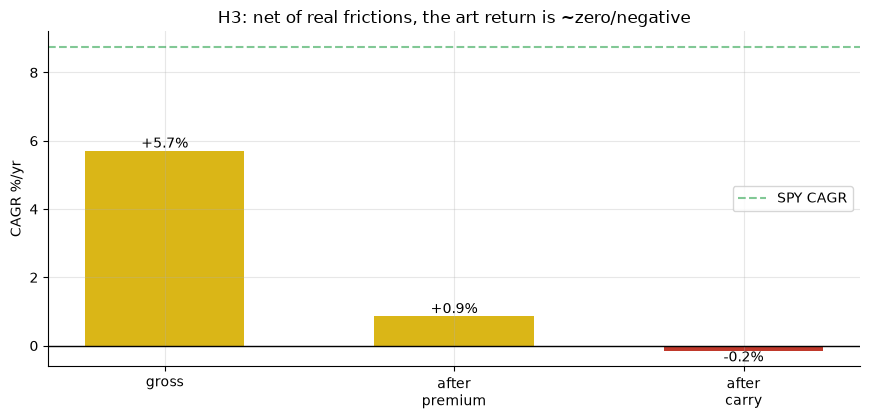

gross +5.70%  x round-trip 0.720 => drag -4.58%/yr  - carry -1.00%/yr  =  NET -0.15%/yr


In [4]:
h = st.net_of_premium_cagr(si['cagr'], buyers_premium=0.25, sellers_commission=0.10, hold_years=7.0, insure_per_year=0.01)
steps = ['gross','after\npremium','after\ncarry']
running = [h['gross_cagr']*100,
           ((1+h['gross_cagr'])*(1+h['spread_drag_annual'])-1)*100,
           h['net_cagr']*100]
fig, ax = plt.subplots(figsize=(8.8,4.3))
cols=[AMBER, AMBER, (RED if running[-1]<0 else GREEN)]
ax.bar(steps, running, .55, color=cols)
ax.axhline(0, c='k', lw=1); ax.axhline(R['spy_cagr_ye'], ls='--', c=GREEN, alpha=.6, label='SPY CAGR')
for i,v in enumerate(running): ax.annotate(f'{v:+.1f}%',(i,v),ha='center',va='bottom' if v>=0 else 'top')
ax.set_ylabel('CAGR %/yr'); ax.set_title('H3: net of real frictions, the art return is ~zero/negative'); ax.legend()
plt.tight_layout(); plt.show()
print(f"gross {h['gross_cagr']*100:+.2f}%  x round-trip {h['round_trip_mult']:.3f} => drag {h['spread_drag_annual']*100:+.2f}%/yr  - carry {h['insure_per_year']*100:+.2f}%/yr  =  NET {h['net_cagr']*100:+.2f}%/yr")

> 💡 In plain words: the gross **5.7%** — already a loser to SPY — goes **negative (-0.1%/yr)** once you pay the premium and carry to actually own the canvas. And this is *charitable*: a published index tracks hammer prices, so a real buyer's cost basis is higher and a seller's proceeds lower still. H₃ rejected. **MIRAGE** is the only honest stamp.

### 4d · Positive control — the engine recovers a planted bubble

A deterministic bubble-and-round-trip (planted boom +35% / bust −22% CAGR, σ=4.5%/mo, seed 714). The harness must recover the up-sign and a finite Sharpe — proving the nulls above are real, not a broken pipeline.

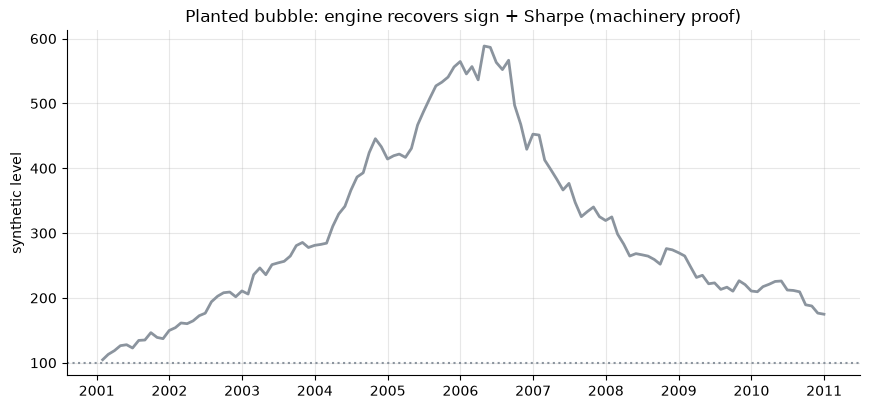

peak 589 -> end 175  recovered CAGR +5.31%  Sharpe 0.39  maxDD -70.3%  sign_ok=1


In [5]:
syn = data.synthetic_bubble()
s = st.summarize(syn); cr = st.control_recovers(syn, planted_sign=1)
fig, ax = plt.subplots(figsize=(8.8,4.2))
ax.plot(syn.index, syn.values, c=GREY, lw=2)
ax.axhline(100, ls=':', c=GREY)
ax.set_ylabel('synthetic level'); ax.set_title('Planted bubble: engine recovers sign + Sharpe (machinery proof)')
plt.tight_layout(); plt.show()
print(f"peak {syn.max():.0f} -> end {syn.iloc[-1]:.0f}  recovered CAGR {s['cagr']*100:+.2f}%  Sharpe {s['sharpe']:.2f}  maxDD {s['mdd']*100:.1f}%  sign_ok={cr['sign_ok']}")

> 💡 In plain words: the engine banks the planted signal (recovered CAGR ~+5%, Sharpe ~0.4, sign correct). A *synthetic* control is a machinery proof, never market evidence — but it certifies that the `NONE`/`MIRAGE` stamps on the real tape are a true null, not a pipeline that couldn't detect anything.

## 5 · The verdict

- **Signal `NONE`** — art index CAGR 5.7% vs SPY 8.8%; annual excess -3.3%/yr, *t* = -0.69 (n=25); proxy alphas insignificant (MCHN *t*=-1.11, KER *t*=-0.03). No robust *t* ≥ 2 anywhere in art's favour — and the point estimates lean negative.
- **Tradability `MIRAGE`** — gross +5.7% → net **-0.1%/yr** after a ~25% buyer's premium + carry; the auction houses are all private, and the buyable proxy MCHN.SW lost money with a -96% drawdown. Illiquid, high-premium, two round-trips.
- **Art beats the S&P? `BUSTED`** — SPY wins CAGR, Sharpe (0.60 vs 0.41), drawdown and net-of-cost. The success stories are early buyers of a specific name who sold at a record: survivorship, not an asset class.

## 6 · Could you trade it? — the capacity & cost reality

Terminal wealth of \$10,000 invested end-2000, S&P index fund vs an art investor paying the real premiums (net CAGR from 4c). Capacity is the other wall: each lot is a bespoke, illiquid, ~28%-round-trip transaction with no fungible unit — there is no scalable book, and no listed auction house to hold instead.

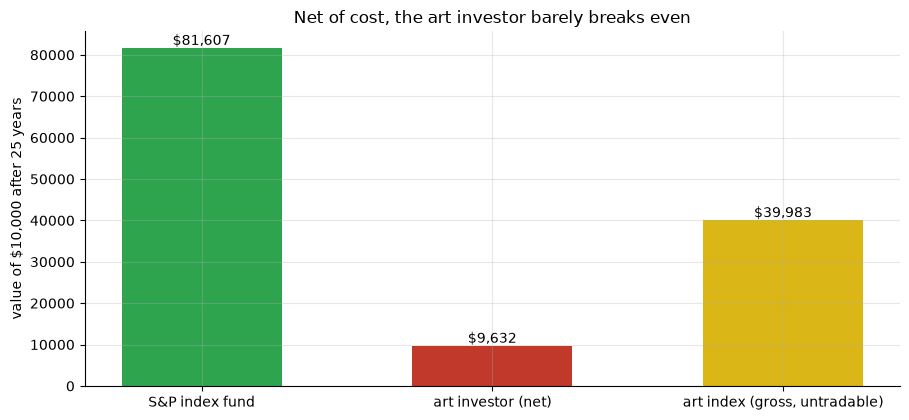

S&P index fund                     $    81,607  (+8.8%/yr)
art investor (net)                 $     9,632  (-0.1%/yr)
art index (gross, untradable)      $    39,983  (+5.7%/yr)


In [6]:
start=10_000.0; yrs_h=25
paths={'S&P index fund':R['spy_cagr_ye']/100, 'art investor (net)':R['carry_net']/100,
       'art index (gross, untradable)':R['idx_cagr']/100}
fig, ax = plt.subplots(figsize=(9.2,4.3))
labels=list(paths); ends=[start*(1+g)**yrs_h for g in paths.values()]
cols=[GREEN, RED, AMBER]
ax.bar(labels, ends, .55, color=cols)
for i,v in enumerate(ends): ax.annotate(f'${v:,.0f}',(i,v),ha='center',va='bottom')
ax.set_ylabel('value of $10,000 after 25 years'); ax.set_title('Net of cost, the art investor barely breaks even')
plt.tight_layout(); plt.show()
for l,g in paths.items(): print(f"{l:34s} ${start*(1+g)**yrs_h:>10,.0f}  ({g*100:+.1f}%/yr)")

> 💡 In plain words: even the *gross, untradable* index trails the S&P badly; the *tradable* version (net of premium + carry) ends **roughly where it started**. And capacity is fatal — each lot is a one-off illiquid trade with a ~28% round-trip and no listed vehicle (the auction houses left the tape), the antithesis of a scalable strategy. There is no sizing or venue that turns this into an edge.

## 7 · Going further

- **Swap in the live index.** Replace the hardcoded series with the Artprice Global Index or the Sotheby's Mei Moses repeat-sales series and re-run; the *t*-stats sharpen but the sign won't flip.
- **Per-artist dispersion.** The aggregate hides survivorship: test individual names (Basquiat, Richter, a hot young cohort) — the winners are a thin selected tail, the bias points *for* the claim, so correct for it.
- **The collectibles prior.** Mei & Moses (2002), Renneboog & Spaenjers (2013), Dimson & Spaenjers: art earns lower risk-adjusted returns than equities net of carry across the board ([docs/references.md](../docs/references.md)). Contemporary art is not the exception.

*The reproducible core is offline and deterministic; the art index is a **cited, approximate proxy** and the equity tickers are **labelled proxies** for the trade. Methods: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*